# import necessart libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Explore data

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [4]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7038,7039,15668679,Ozerova,630,France,Male,31,0,0.00,2,1,1,34475.14,0
3453,3454,15737521,Ball,619,Germany,Male,40,9,103604.31,2,0,0,140947.05,0
7979,7980,15627042,Reilly,555,France,Female,26,7,0.00,2,1,0,93122.41,0
5588,5589,15704771,Ugochukwu,593,France,Female,35,6,133489.12,2,1,1,78101.29,0
6247,6248,15803633,T'ien,678,France,Female,46,1,0.00,2,0,0,82106.19,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [7]:
df.describe(include='object').T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


In [8]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
numeric_features = df.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
categorical_features = df.select_dtypes(include=[object]).columns.tolist()

In [11]:
numeric_features

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [12]:
categorical_features

['Geography', 'Gender']

# visualiza data

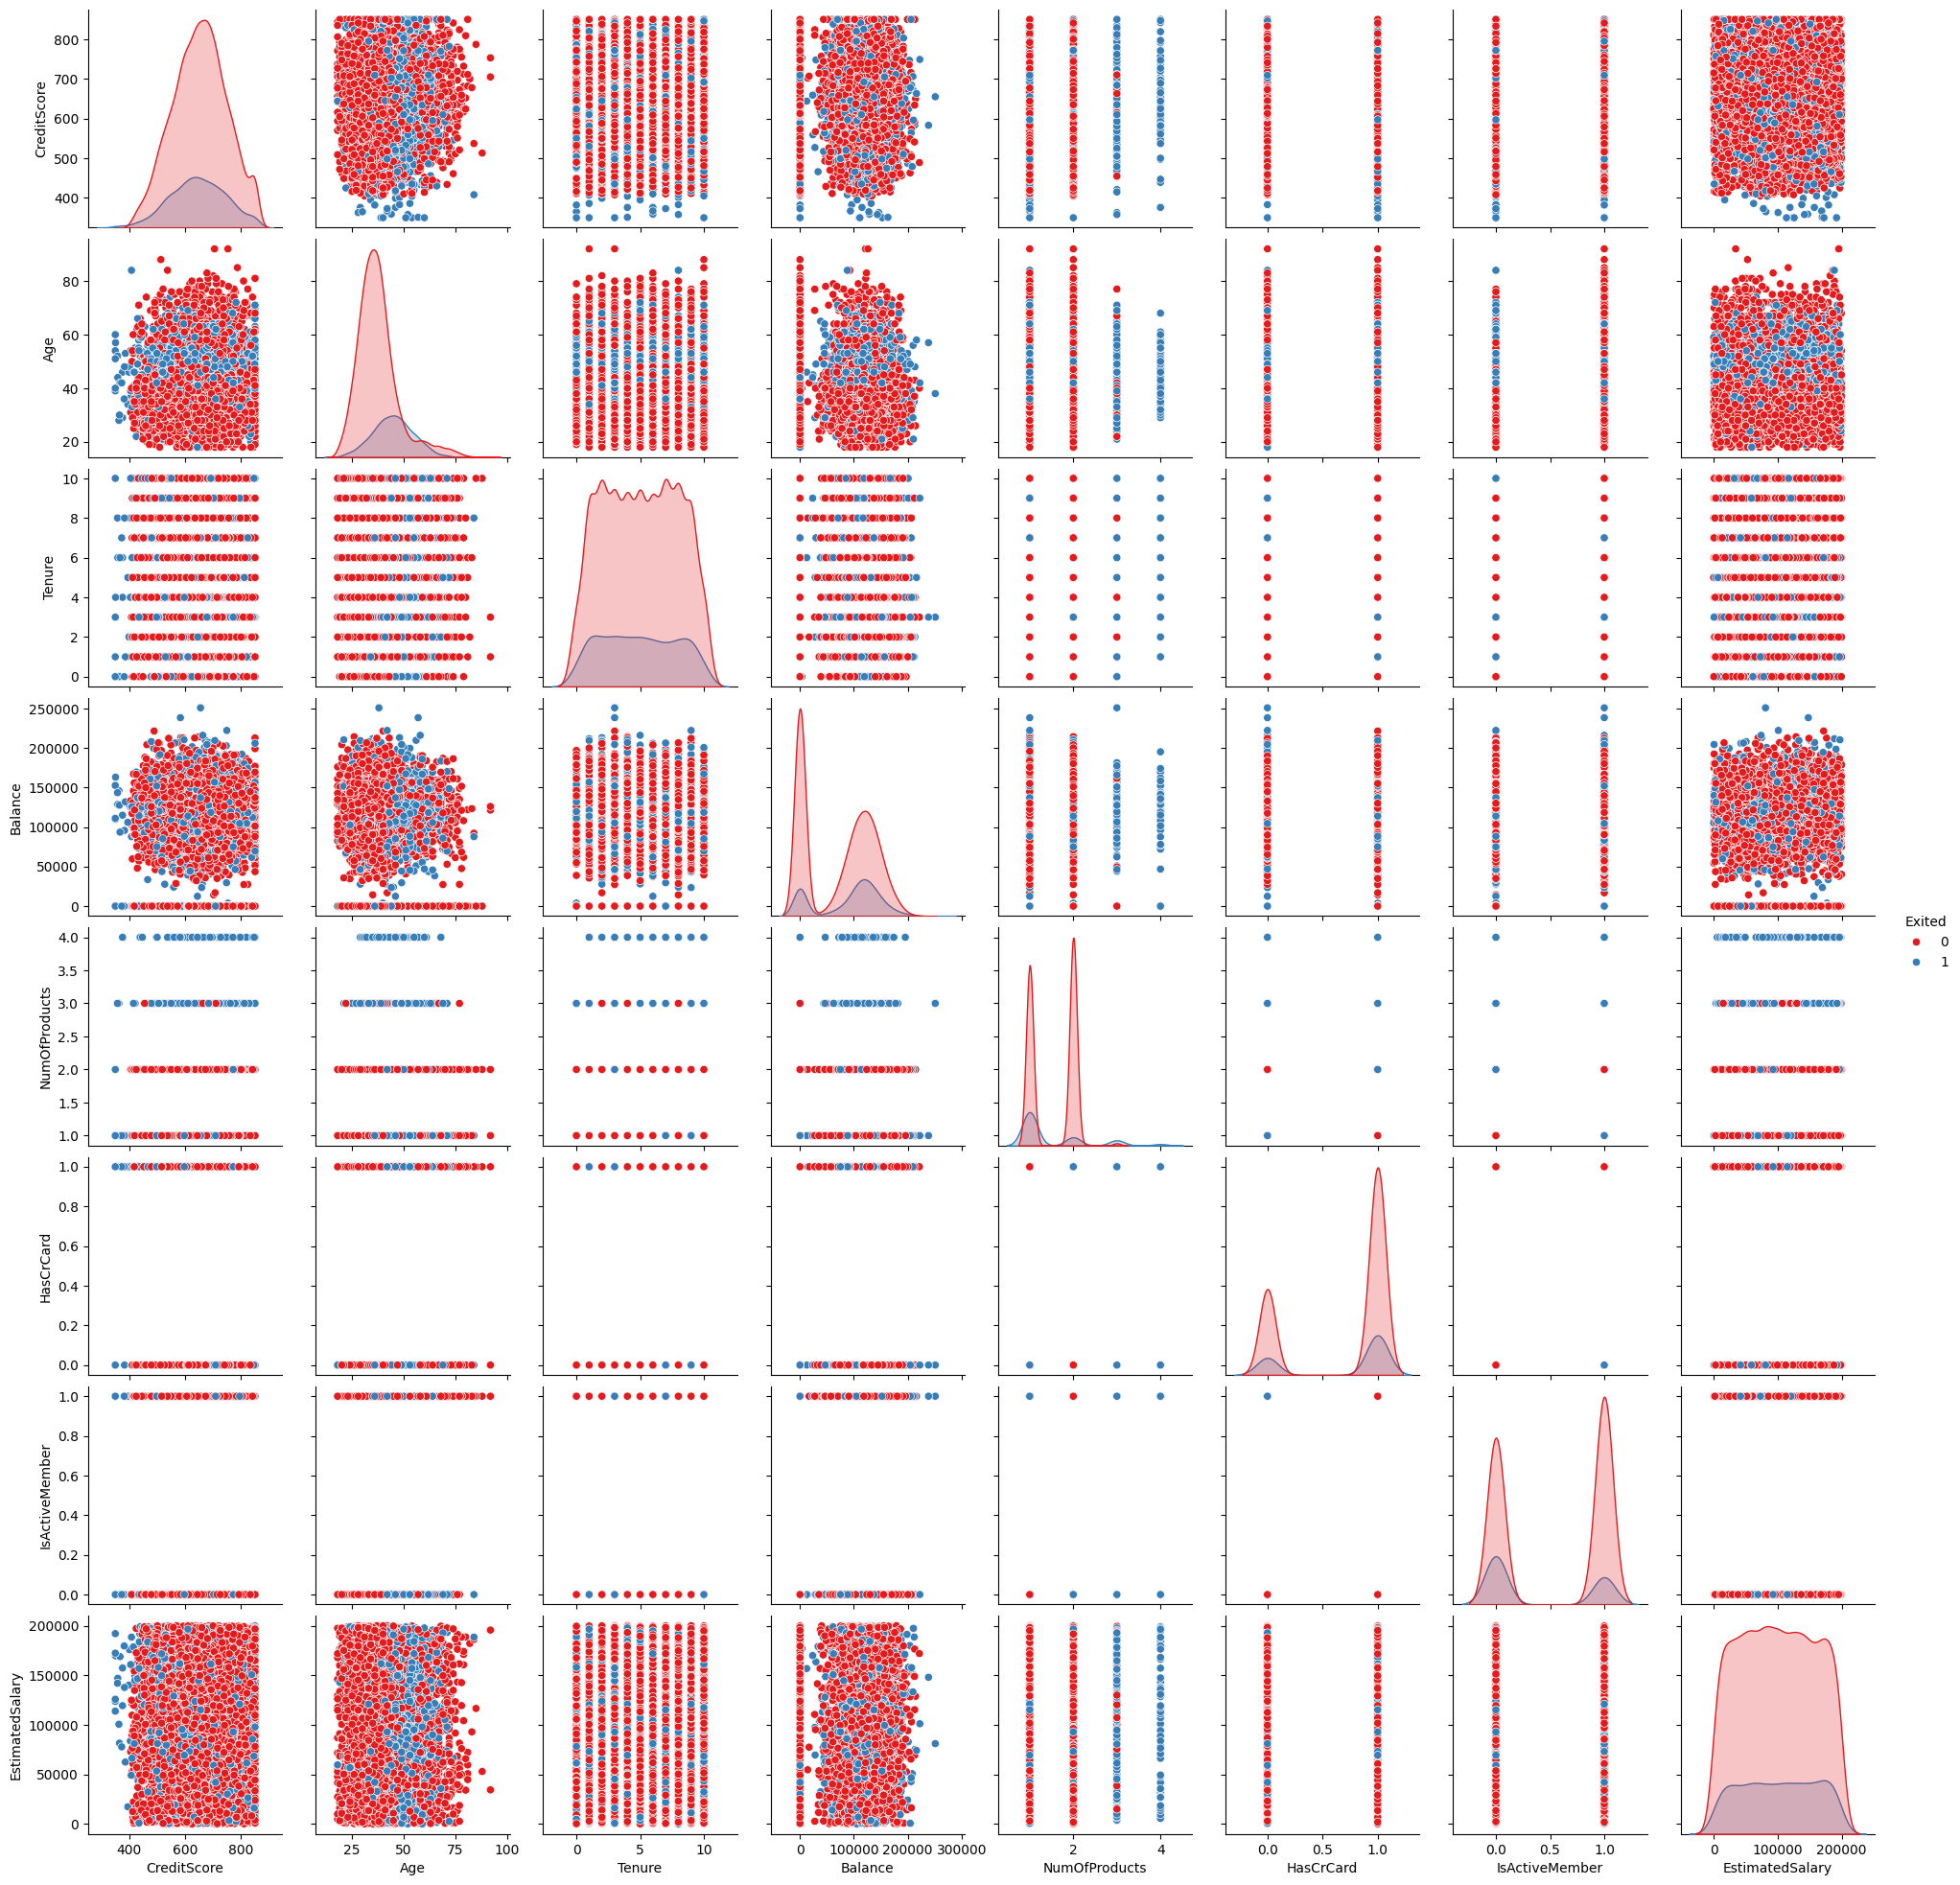

In [ ]:
numeric_features = df.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
# apply pair plot on numerical features
sns.pairplot(df[numeric_features], diag_kind='kde', markers='o', hue='Exited', palette='Set2')

In [14]:
# For continuous data
numerical_cols = df.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
numerical_cols.remove('Exited')  # Exited is the target variable
continuous_columns = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

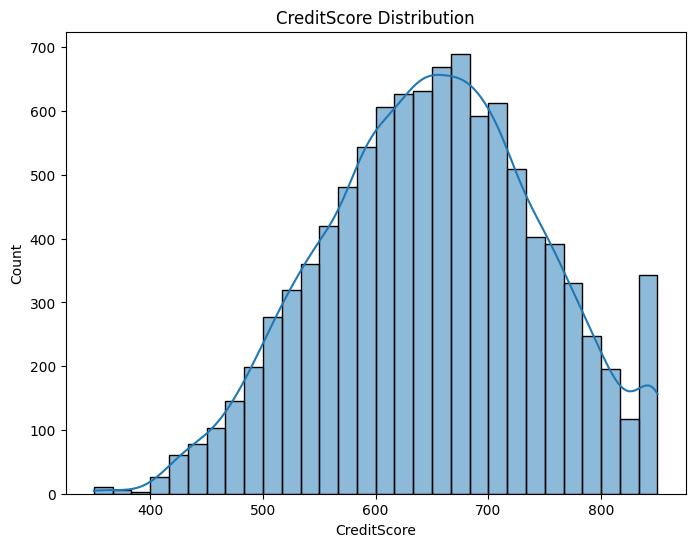

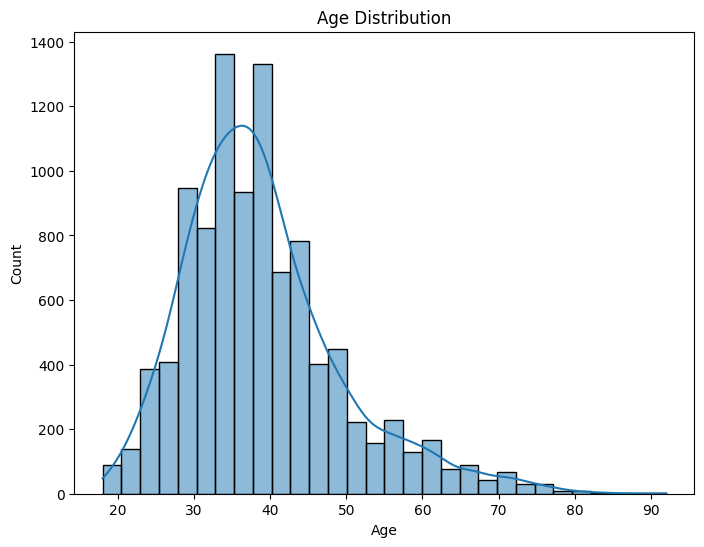

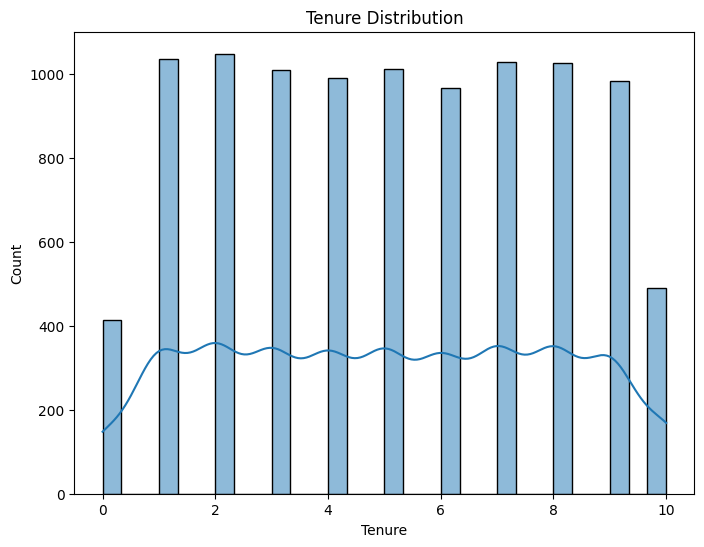

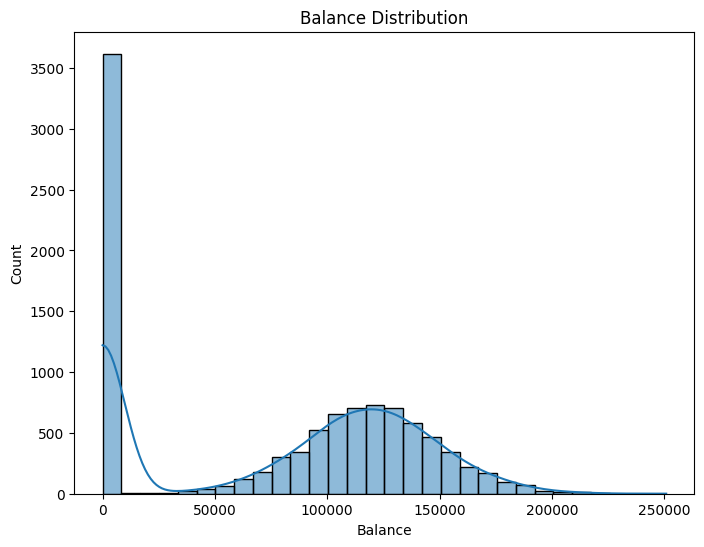

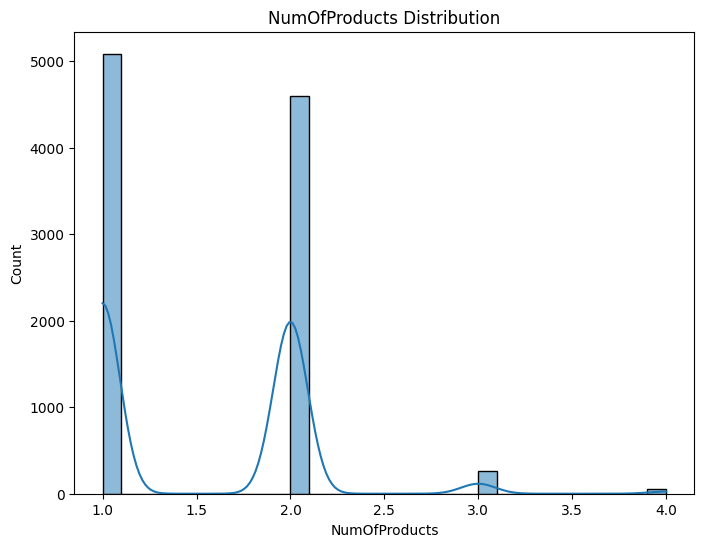

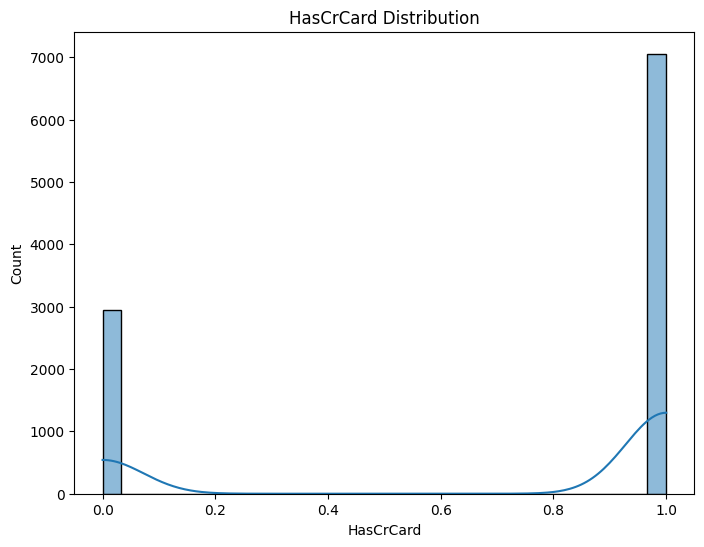

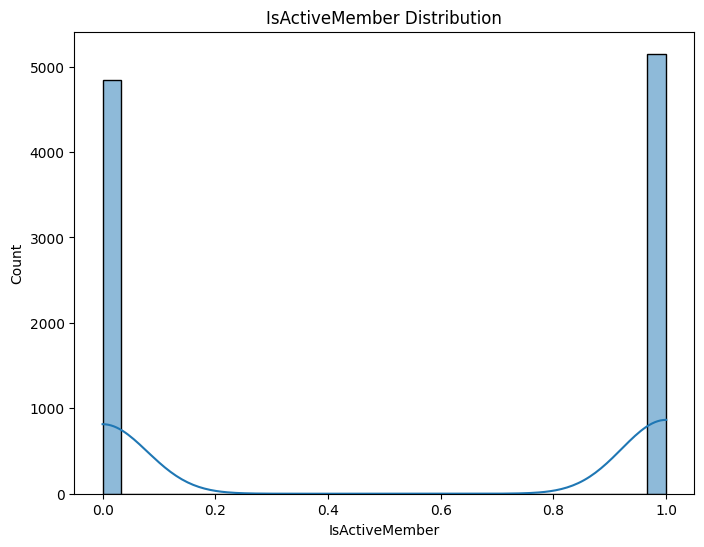

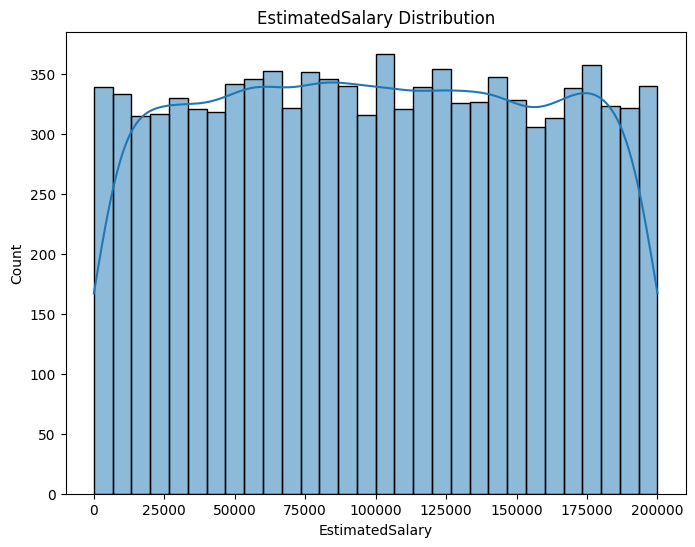

In [15]:
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True, bins=30)  
    plt.title(f'{col} Distribution')
    plt.show()

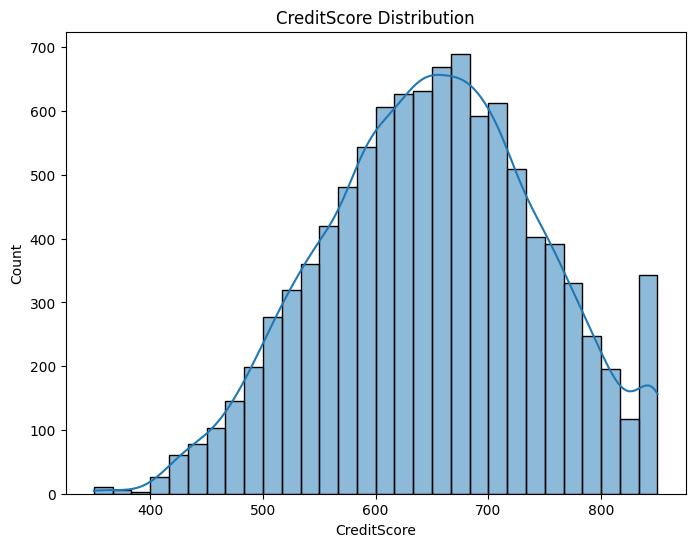

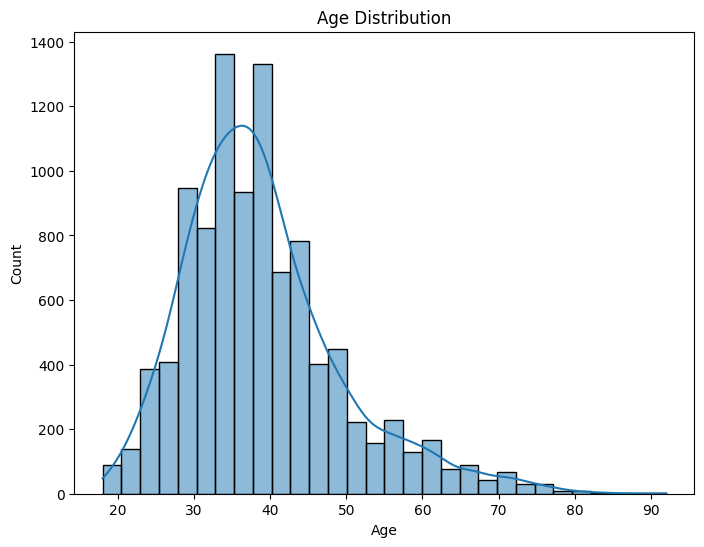

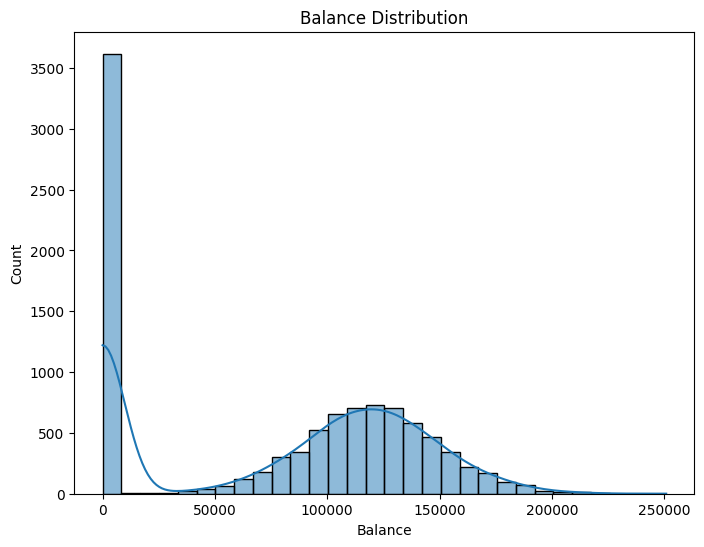

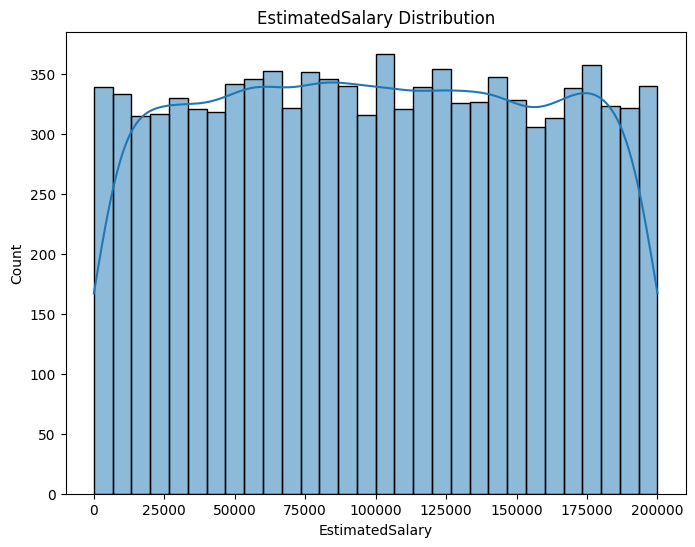

In [16]:
for col in continuous_columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True, bins=30)  
    plt.title(f'{col} Distribution')
    plt.show()

# check on correaltion between features

In [17]:
continuous = df.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
continuous.remove('Exited')  # Exited is the target variable
continuous

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [18]:
continuous = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

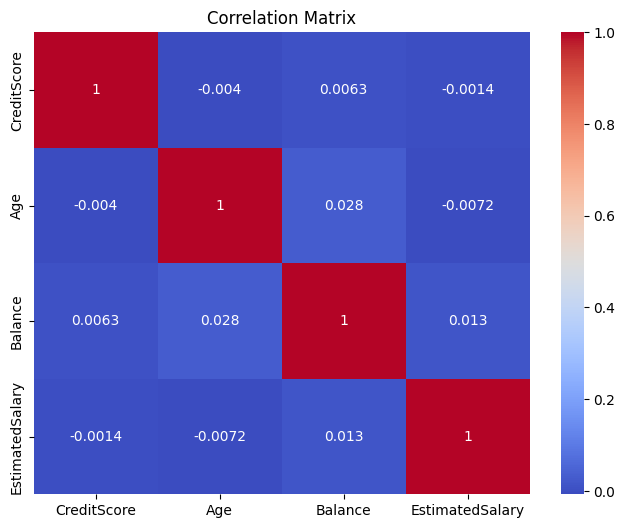

In [19]:
# Check correlation between continuous features
plt.figure(figsize=(8, 6))
sns.heatmap(df[continuous].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

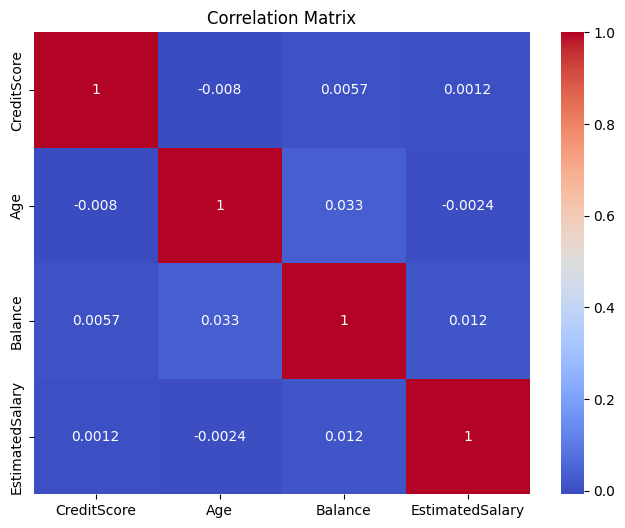

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[continuous].corr(method='spearman'), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

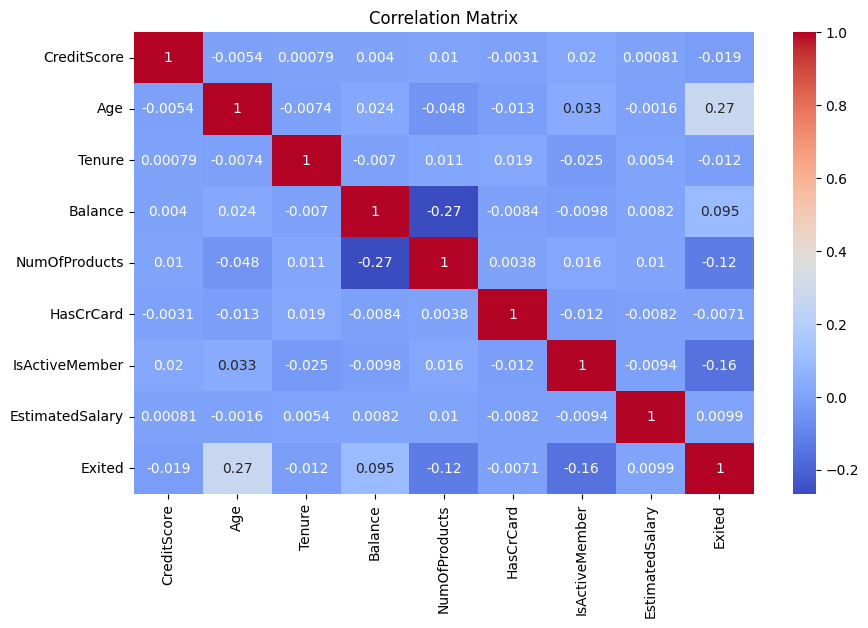

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_features].corr(method='kendall'), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# check missing values

In [15]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# check duplicates

In [16]:
df.duplicated().sum()

np.int64(0)

# check on imbalanced dataset

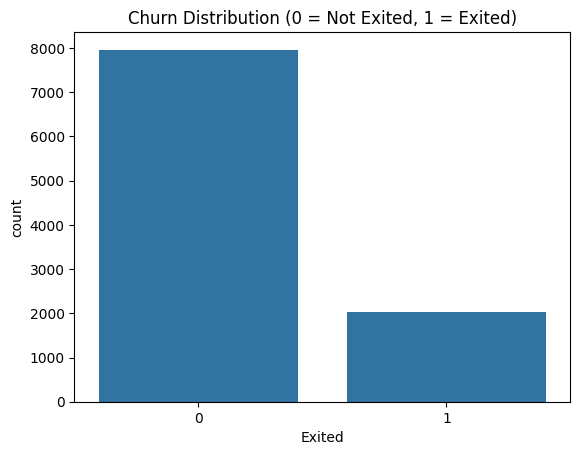

In [17]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution (0 = Not Exited, 1 = Exited)")
plt.show()

# check on outliers

In [27]:
# Select numerical columns only
numeric_features = df.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
numeric_features.remove("Exited")  # Don't check outliers in the target column

In [28]:
numeric_features

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [29]:
# Function to calculate outliers using IQR
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers

# Check outliers in each numerical column
for col in numeric_features:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

CreditScore: 15 outliers
Age: 359 outliers
Tenure: 0 outliers
Balance: 0 outliers
NumOfProducts: 60 outliers
HasCrCard: 0 outliers
IsActiveMember: 0 outliers
EstimatedSalary: 0 outliers


# box plot 
يستخدم مع ال IQR



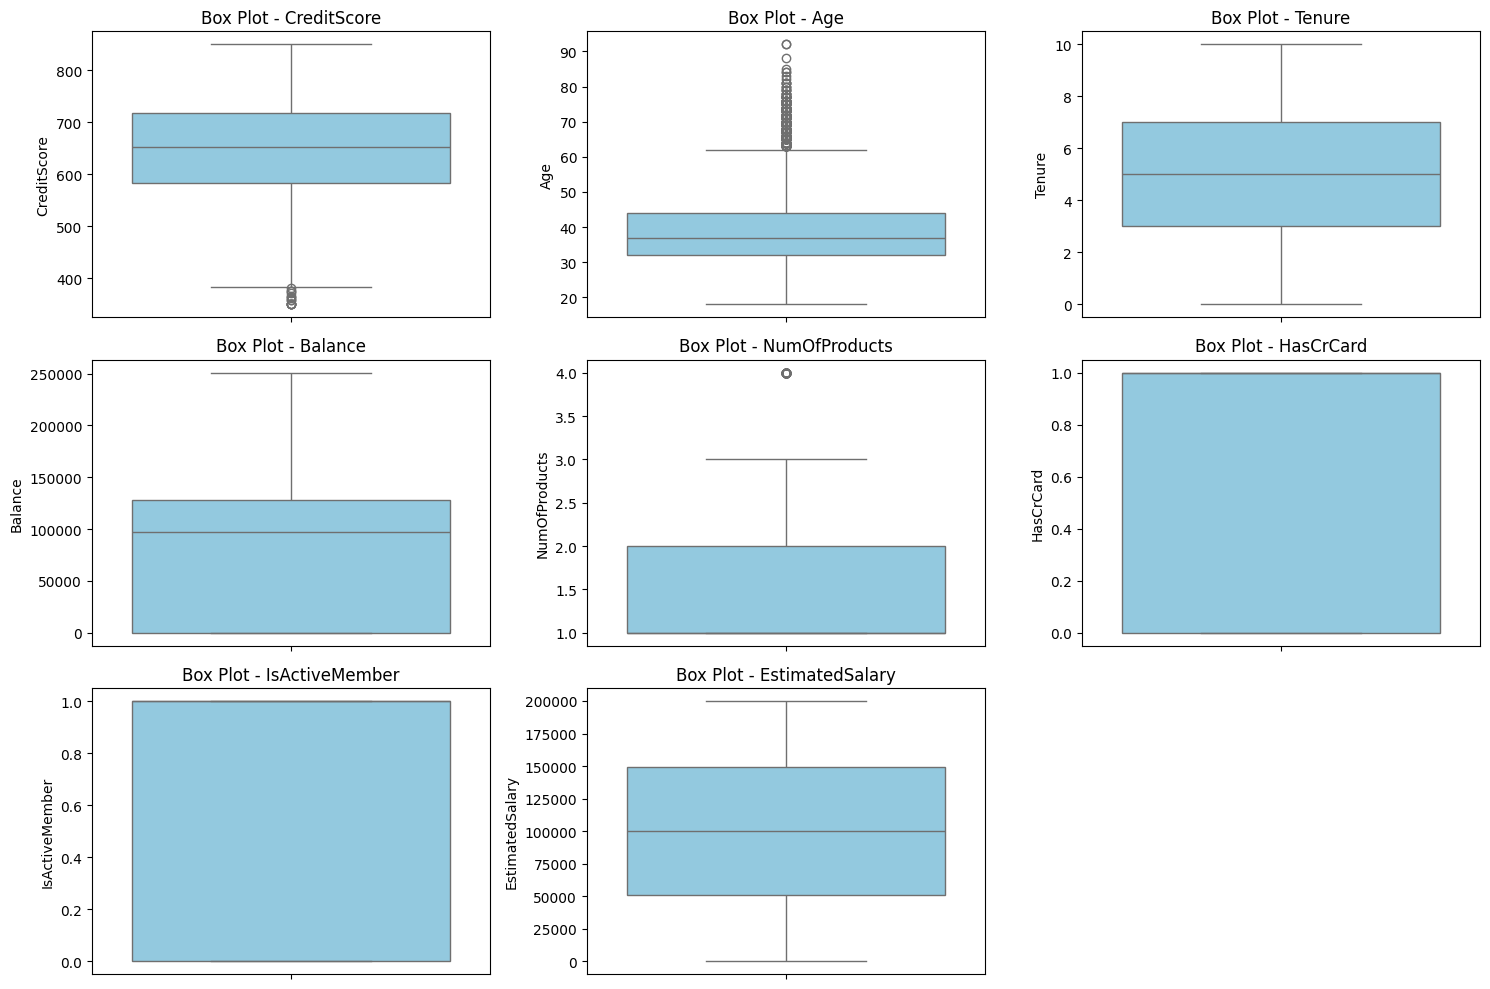

In [22]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot - {col}')
plt.tight_layout()
plt.show()

In [ ]:
def cap_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR  
    upper_bound = Q3 + 1.5 * IQR
    data[feature] = np.where(data[feature] < lower_bound, lower_bound,
                     np.where(data[feature] > upper_bound, upper_bound, data[feature]))
    return data

# Apply capping to all numeric features (except target)
for col in numeric_features:
    df = cap_outliers_iqr(df, col)

In [24]:
# Check outliers in each numerical column
for col in numeric_features:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

CreditScore: 0 outliers
Age: 0 outliers
Tenure: 0 outliers
Balance: 0 outliers
NumOfProducts: 0 outliers
HasCrCard: 0 outliers
IsActiveMember: 0 outliers
EstimatedSalary: 0 outliers


# apply robust scaling on cols that have outliers

In [30]:
# Check outliers in each numerical column
outliers_cols = ['CreditScore', 'Age', 'NumOfProducts']
for col in outliers_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

CreditScore: 15 outliers
Age: 359 outliers
NumOfProducts: 60 outliers


In [31]:
from sklearn.preprocessing import RobustScaler

# Apply robust scaling on cols that have outliers
for col in outliers_cols:
    scaler = RobustScaler()
    df[col] = scaler.fit_transform(df[[col]])   

In [36]:
df[["CreditScore", "Age", "NumOfProducts"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,-0.010979,0.721293,-2.253731,-0.507463,0.0,0.492537,1.477612
Age,10000.0,0.160150,0.873984,-1.583333,-0.416667,0.0,0.583333,4.583333
NumOfProducts,10000.0,0.530200,0.581654,0.000000,0.000000,0.0,1.000000,3.000000


In [32]:
# Check outliers in each numerical column
outliers_cols = ['CreditScore', 'Age', 'NumOfProducts']
for col in outliers_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

CreditScore: 15 outliers
Age: 359 outliers
NumOfProducts: 60 outliers


# apply standard scaler 

In [37]:
from sklearn.preprocessing import StandardScaler

# Apply robust scaling on cols that have outliers
for col in outliers_cols:
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])   

In [38]:
df[["CreditScore", "Age", "NumOfProducts"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,2.344791e-17,1.00005,-3.109504,-0.688359,0.015222,0.698109,2.063884
Age,10000.0,1.971756e-17,1.00005,-1.994969,-0.660018,-0.183251,0.484225,5.061197
NumOfProducts,10000.0,1.634248e-17,1.00005,-0.911583,-0.911583,-0.911583,0.807737,4.246377


In [39]:
# Check outliers in each numerical column
outliers_cols = ['CreditScore', 'Age', 'NumOfProducts']
for col in outliers_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

CreditScore: 16 outliers
Age: 359 outliers
NumOfProducts: 60 outliers


# handle categorical data

In [45]:
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())
    print("-----")

Geography: 3 unique values
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
-----
Gender: 2 unique values
Gender
Male      5457
Female    4543
Name: count, dtype: int64
-----


In [46]:
df.shape

(10000, 11)

In [47]:
# One-hot encoding with drop_first to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,2,0.00,-0.911583,1,1,101348.88,1,False,False,False
1,-0.440036,0.198164,1,83807.86,-0.911583,0,1,112542.58,0,False,True,False
2,-1.536794,0.293517,8,159660.80,2.527057,1,0,113931.57,1,False,False,False
3,0.501521,0.007457,1,0.00,0.807737,0,0,93826.63,0,False,False,False
4,2.063884,0.388871,2,125510.82,-0.911583,1,1,79084.10,0,False,True,False


In [54]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

ohe = OneHotEncoder(sparse_output=False, drop='first')

ct = make_column_transformer(
    (ohe, categorical_features),
    remainder='passthrough'  # Keep the rest of the columns unchanged
).set_output(transform='pandas')

df_encoded_new = ct.fit_transform(df)
df_encoded_new.head()

,onehotencoder__Geography_Germany,onehotencoder__Geography_Spain,onehotencoder__Gender_Male,remainder__CreditScore,remainder__Age,remainder__Tenure,remainder__Balance,remainder__NumOfProducts,remainder__HasCrCard,remainder__IsActiveMember,remainder__EstimatedSalary,remainder__Exited
0,0.0,0.0,0.0,-0.326221,0.293517,2,0.00,-0.911583,1,1,101348.88,1
1,0.0,1.0,0.0,-0.440036,0.198164,1,83807.86,-0.911583,0,1,112542.58,0
2,0.0,0.0,0.0,-1.536794,0.293517,8,159660.80,2.527057,1,0,113931.57,1
3,0.0,0.0,0.0,0.501521,0.007457,1,0.00,0.807737,0,0,93826.63,0
4,0.0,1.0,0.0,2.063884,0.388871,2,125510.82,-0.911583,1,1,79084.10,0


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])        # Male=1, Female=0
df['Geography'] = le.fit_transform(df['Geography'])  # France=0, Germany=1, Spain=2
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619.0,0,0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1
1,608.0,2,0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0
2,502.0,0,0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1
3,699.0,0,0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0
4,850.0,2,0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0


# Apply feature scaling

In [40]:
features_to_scale = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.000000e+00,2.500750e+03,5.000500e+03,7.500250e+03,1.000000e+04
CustomerId,10000.0,1.569094e+07,71936.186123,1.556570e+07,1.562853e+07,1.569074e+07,1.575323e+07,1.581569e+07
CreditScore,10000.0,-4.824585e-16,1.000050,-3.109504e+00,-6.883586e-01,1.522218e-02,6.981094e-01,2.063884e+00
Age,10000.0,2.318146e-16,1.000050,-1.994969e+00,-6.600185e-01,-1.832505e-01,4.842246e-01,5.061197e+00
Tenure,10000.0,5.012800e+00,2.892174,0.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,1.000000e+01
Balance,10000.0,-6.252776e-17,1.000050,-1.225848e+00,-1.225848e+00,3.319639e-01,8.199205e-01,2.795323e+00
NumOfProducts,10000.0,1.530200e+00,0.581654,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00
HasCrCard,10000.0,7.055000e-01,0.455840,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
EstimatedSalary,10000.0,-2.877698e-17,1.000050,-1.740268e+00,-8.535935e-01,1.802807e-03,8.572431e-01,1.737200e+00


In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [44]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,0.601058,0.282727,5.012800,0.304848,1.530200,0.70550,0.515100,0.500441,0.203700
std,2886.89568,7.193619e+04,0.193307,0.141727,2.892174,0.248696,0.581654,0.45584,0.499797,0.287580,0.402769
min,1.00000,1.556570e+07,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000
25%,2500.75000,1.562853e+07,0.468000,0.189189,3.000000,0.000000,1.000000,0.00000,0.000000,0.254977,0.000000
50%,5000.50000,1.569074e+07,0.604000,0.256757,5.000000,0.387402,1.000000,1.00000,1.000000,0.500960,0.000000
75%,7500.25000,1.575323e+07,0.736000,0.351351,7.000000,0.508749,2.000000,1.00000,1.000000,0.746955,0.000000
max,10000.00000,1.581569e+07,1.000000,1.000000,10.000000,1.000000,4.000000,1.00000,1.000000,1.000000,1.000000


# train test split

In [70]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [48]:
x=df_encoded.drop(['Exited'],axis=1) # work as a classification problem
y=df_encoded['Exited']
print(x.shape , y.shape)

(10000, 11) (10000,)


c0 500 , c1 500

train_size = 0.8

ytrain --> c0 400 , c1 400 if we use stratify=y


c0 800 , c1 200

train_size = 0.8


ytrain --> c0 640 , c1 160 if we use stratify=y

In [49]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y , shuffle=True)
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,shuffle=True)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8000, 11), (2000, 11), (8000,), (2000,))

In [50]:
# check on value counts oy ytrain , ytest after split
print(y_train.value_counts())
print(y_test.value_counts())

Exited
0    6370
1    1630
Name: count, dtype: int64
Exited
0    1593
1     407
Name: count, dtype: int64


In [51]:
# apply smote oversampling to overcome imbalanced dataset 
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)
x_train.shape, y_train.shape

((12740, 11), (12740,))

In [52]:
# check on value counts oy ytrain , ytest after split
print(y_train.value_counts())
print(y_test.value_counts())

Exited
1    6370
0    6370
Name: count, dtype: int64
Exited
0    1593
1     407
Name: count, dtype: int64


In [76]:
x=df.drop(['EstimatedSalary'],axis=1) # work as a regression problem
y=df['EstimatedSalary']
print(x.shape , y.shape)

(10000, 10) (10000,)


In [77]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,shuffle=True)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8000, 10), (2000, 10), (8000,), (2000,))